# Chapter 14. 일반화 성향점수 (Generalized Propensity Score)

**학습 목표:**
- 연속형 처치변수에서의 인과추론 이해
- 일반화 성향점수(GPS) 추정 방법 습득
- 용량-반응 함수(ADRF) 구축 및 해석
- Hirano & Imbens (2004) 접근법 구현
- LLM을 활용한 처치변수 자동 탐지

## 환경 설정 및 라이브러리 로드

이 튜토리얼에서는 다음 라이브러리를 사용한다:
- `numpy`, `pandas`: 데이터 처리
- `sklearn`: 회귀 분석
- `scipy`: 통계 함수
- `matplotlib`, `seaborn`: 시각화
- `openai`: LLM 기반 처치변수 탐지

In [1]:
# 필요한 라이브러리 설치
import subprocess
import sys

packages = ['openai', 'numpy', 'pandas', 'scikit-learn', 'scipy', 'matplotlib', 'seaborn']
for package in packages:
    try:
        __import__(package.replace('-', '_'))
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

print("라이브러리 설치 완료")

라이브러리 설치 완료


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from scipy.stats import norm
from openai import OpenAI
import json
import warnings

# 시각화 설정
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
warnings.filterwarnings('ignore')

# OpenAI 클라이언트 초기화
client = OpenAI()  # OPENAI_API_KEY 환경변수 필요

print("라이브러리 로드 완료")

라이브러리 로드 완료


## 1. 연속형 처치변수와 인과추론

지금까지 학습한 방법들(RCT, propensity score matching)은 주로 **이진 처치변수**(0 또는 1)를 다루었다.
그러나 현실에서는 연속형 처치변수가 많다:
- **의약학**: 투약량 (dosage)
- **교육**: 학습 시간 (hours of study)
- **경제학**: 교육 수준 (years of schooling)
- **마케팅**: 광고 예산 (advertising spend)

연속형 처치변수에서는 **용량-반응 함수 (Dose-Response Function, ADRF)**를 추정한다:
$$E[Y(t)] = \text{특정 처치 수준 } t \text{ 에서의 기댓값}$$

In [3]:
# 연속형 처치변수 시뮬레이션: 투약량 → 회복율

np.random.seed(42)
n = 500

# 교란변수: 환자의 초기 심각도 (0~10)
X = np.random.uniform(0, 10, n)

# 연속형 처치변수: 투약량 (mg), 심각도에 따라 달라짐
# 더 심각한 환자일수록 더 높은 용량을 처방받음 (교란)
T = 5 + 2 * X + np.random.normal(0, 3, n)
T = np.clip(T, 0, 30)  # 0~30 mg로 제한

# 결과: 회복율 (%)
# 진짜 인과함수: E[Y(t)] = 30 + 8*t - 0.15*t^2 (U자형)
true_treatment_effect = 30 + 8 * T - 0.15 * T**2
Y = true_treatment_effect + 5 * X + np.random.normal(0, 5, n)
Y = np.clip(Y, 0, 100)  # 회복율을 0~100으로 제한

# 데이터프레임 생성
data = pd.DataFrame({
    'X': X,      # 초기 심각도
    'T': T,      # 투약량
    'Y': Y       # 회복율
})

print(f"데이터 크기: {len(data)}")
print(f"\n처치변수 T 기술통계:")
print(data['T'].describe())
print(f"\n결과변수 Y 기술통계:")
print(data['Y'].describe())

데이터 크기: 500

처치변수 T 기술통계:
count    500.000000
mean      14.993222
std        6.869363
min        0.000000
25%       10.122234
50%       15.094109
75%       20.442610
max       30.000000
Name: T, dtype: float64

결과변수 Y 기술통계:
count    500.000000
mean      94.253563
std       13.768803
min       29.441765
25%      100.000000
50%      100.000000
75%      100.000000
max      100.000000
Name: Y, dtype: float64


Naive regression (confounded): treatment coef = 1.3557
(True marginal effect is ~8 - 2*t, positive; naive may be negative)


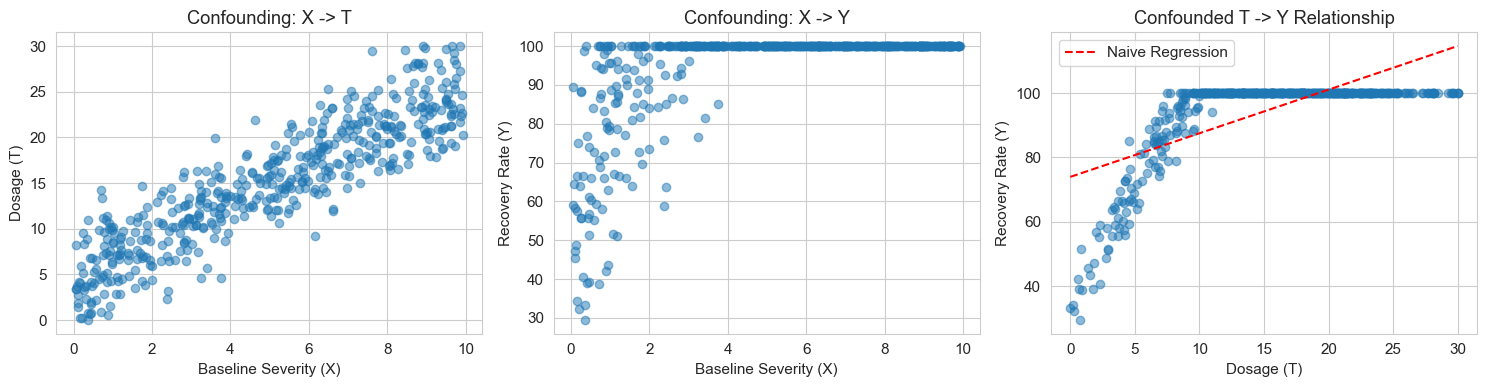

In [4]:
# Naive regression: biased due to confounding

model_naive = LinearRegression()
model_naive.fit(data[['T']], data['Y'])
naive_coef = model_naive.coef_[0]

print(f'Naive regression (confounded): treatment coef = {naive_coef:.4f}')
print(f'(True marginal effect is ~8 - 2*t, positive; naive may be negative)')

# Visualize confounding relationships
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(data['X'], data['T'], alpha=0.5)
axes[0].set_xlabel('Baseline Severity (X)')
axes[0].set_ylabel('Dosage (T)')
axes[0].set_title('Confounding: X -> T')

axes[1].scatter(data['X'], data['Y'], alpha=0.5)
axes[1].set_xlabel('Baseline Severity (X)')
axes[1].set_ylabel('Recovery Rate (Y)')
axes[1].set_title('Confounding: X -> Y')

axes[2].scatter(data['T'], data['Y'], alpha=0.5)
z = np.polyfit(data['T'], data['Y'], 1)
p = np.poly1d(z)
t_line = np.linspace(data['T'].min(), data['T'].max(), 100)
axes[2].plot(t_line, p(t_line), 'r--', label='Naive Regression')
axes[2].set_xlabel('Dosage (T)')
axes[2].set_ylabel('Recovery Rate (Y)')
axes[2].set_title('Confounded T -> Y Relationship')
axes[2].legend()

plt.tight_layout()
plt.show()


## 2. 일반화 성향점수 (GPS) 추정

**일반화 성향점수(GPS)**는 이진 처치의 propensity score를 연속형으로 확장한 개념이다:

$$r(t, X) = f_{T|X}(t|X)$$

즉, 주어진 공변수 X에서 처치값 T=t를 받을 **조건부 확률밀도** 이다.

정규분포 가정 하에서:
- $T|X \sim N(\beta_0 + \beta'X, \sigma^2)$
- $r_i = \frac{1}{\sqrt{2\pi\sigma^2}} \cdot \exp\left(-\frac{(T_i - \hat{\beta}_0 - \hat{\beta}'X_i)^2}{2\sigma^2}\right)$

In [5]:
# Step 1: T|X 회귀 분석 (OLS)

X_with_const = np.column_stack([np.ones(n), data[['X']].values])

# OLS 회귀
model_treatment = LinearRegression(fit_intercept=True)
model_treatment.fit(data[['X']], data['T'])

# 예측값과 잔차
T_pred = model_treatment.predict(data[['X']])
residuals = data['T'] - T_pred

# 조건부 분산 추정
sigma_squared = np.mean(residuals**2)
sigma = np.sqrt(sigma_squared)

print(f"처치 모델: T = {model_treatment.intercept_:.4f} + {model_treatment.coef_[0]:.4f} * X")
print(f"조건부 분산 σ² = {sigma_squared:.4f}")
print(f"조건부 표준편차 σ = {sigma:.4f}")

처치 모델: T = 4.6854 + 2.0675 * X
조건부 분산 σ² = 9.0342
조건부 표준편차 σ = 3.0057


GPS descriptive statistics:
count    500.000000
mean       0.093235
std        0.037160
min        0.001445
25%        0.067840
50%        0.106203
75%        0.125591
max        0.132729
Name: GPS, dtype: float64


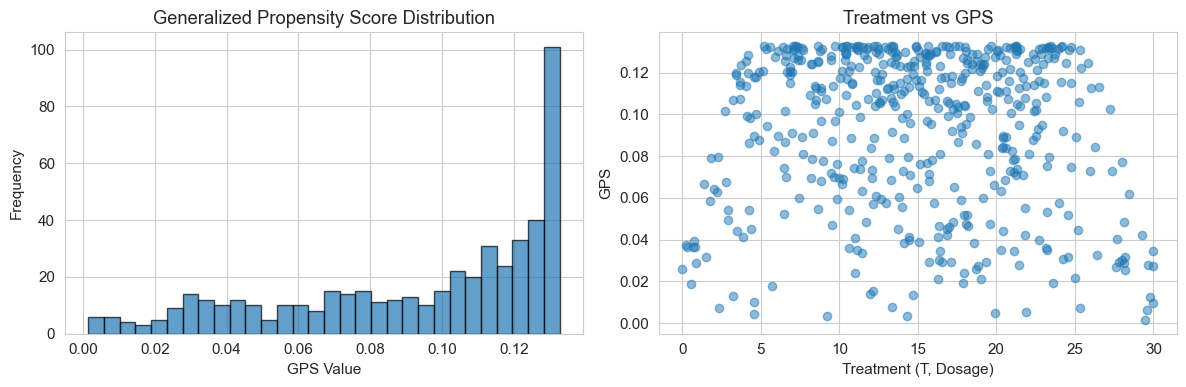

In [6]:
# Step 2: Compute GPS values

def compute_gps(T, T_pred, sigma):
    """
    Generalized Propensity Score computation

    GPS = phi((T - T_pred) / sigma) / sigma
    where phi is the standard normal PDF
    """
    standardized = (T - T_pred) / sigma
    gps = norm.pdf(standardized) / sigma
    return gps

data['GPS'] = compute_gps(data['T'].values, T_pred, sigma)

print(f'GPS descriptive statistics:')
print(data['GPS'].describe())

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# GPS distribution
axes[0].hist(data['GPS'], bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('GPS Value')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Generalized Propensity Score Distribution')

# Treatment vs GPS
axes[1].scatter(data['T'], data['GPS'], alpha=0.5)
axes[1].set_xlabel('Treatment (T, Dosage)')
axes[1].set_ylabel('GPS')
axes[1].set_title('Treatment vs GPS')

plt.tight_layout()
plt.show()


## 3. 결과 모델 적합

GPS를 사용하여 교란을 제어하는 결과 모델을 적합한다:

$$E[Y|T, R] = \alpha_0 + \alpha_1 T + \alpha_2 T^2 + \alpha_3 R + \alpha_4 R^2 + \alpha_5 T \cdot R$$

여기서 R = GPS는 교란을 조정하는 역할을 한다.

In [7]:
# 결과 모델 피처 생성

X_outcome = np.column_stack([
    np.ones(n),
    data['T'].values,
    data['T'].values**2,
    data['GPS'].values,
    data['GPS'].values**2,
    data['T'].values * data['GPS'].values
])

# 결과 모델 회귀
model_outcome = LinearRegression(fit_intercept=False)
model_outcome.fit(X_outcome, data['Y'])

Y_pred = model_outcome.predict(X_outcome)
residuals_outcome = data['Y'] - Y_pred
rmse = np.sqrt(np.mean(residuals_outcome**2))

coef_names = ['상수항', 'T', 'T²', 'GPS', 'GPS²', 'T×GPS']
for name, coef in zip(coef_names, model_outcome.coef_):
    print(f"{name:10s}: {coef:10.4f}")

print(f"\nRMSE: {rmse:.4f}")
print(f"R²: {1 - np.sum(residuals_outcome**2) / np.sum((data['Y'] - data['Y'].mean())**2):.4f}")

상수항       :    39.7338
T         :     6.7070
T²        :    -0.1620
GPS       :    41.3900
GPS²      :   373.7747
T×GPS     :    -6.9665

RMSE: 5.2844
R²: 0.8524


## 4. ADRF (용량-반응 곡선) 추정

**평균 용량-반응 함수 (Average Dose-Response Function, ADRF)**를 추정한다:

$$\hat{ADRF}(t) = E[Y|T=t, R=r(t, X)]$$

이는 각 처치 수준 $t$ 에 대해 모든 표본의 GPS를 고정된 수준에서 평가한 후, 결과의 평균을 구하는 방식이다.

In [8]:
# ADRF 계산

t_grid = np.linspace(data['T'].min(), data['T'].max(), 30)
adrf_estimate = []

for t_val in t_grid:
    # 모든 표본에 대해 처치값을 t_val로 설정
    T_counterfactual = np.full(n, t_val)
    T_pred_for_gps = model_treatment.predict(data[['X']])
    GPS_at_t = compute_gps(T_counterfactual, T_pred_for_gps, sigma)
    
    # 결과 예측
    X_outcome_cf = np.column_stack([
        np.ones(n),
        T_counterfactual,
        T_counterfactual**2,
        GPS_at_t,
        GPS_at_t**2,
        T_counterfactual * GPS_at_t
    ])
    Y_cf = model_outcome.predict(X_outcome_cf)
    
    # 평균을 취함
    adrf_estimate.append(np.mean(Y_cf))

adrf_estimate = np.array(adrf_estimate)

print(f"ADRF 계산 완료: {len(t_grid)}개 처치 수준")
print(f"\nADRF 범위: [{adrf_estimate.min():.2f}, {adrf_estimate.max():.2f}]")

ADRF 계산 완료: 30개 처치 수준

ADRF 범위: [39.90, 106.16]


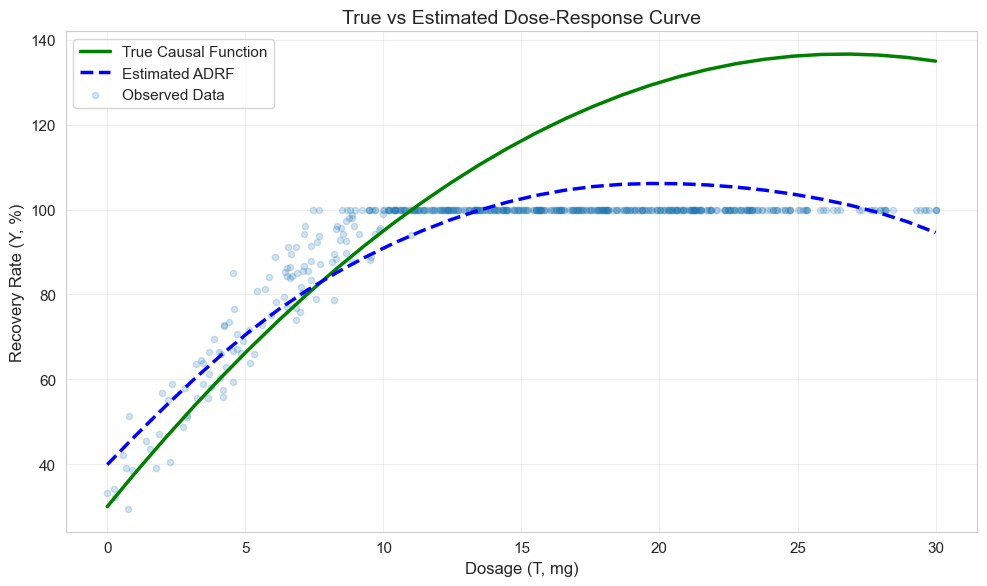

ADRF estimation error (RMSE): 21.4009


In [9]:
# True ADRF vs Estimated ADRF

true_adrf = 30 + 8 * t_grid - 0.15 * t_grid**2

# Visualization
plt.figure(figsize=(10, 6))
plt.plot(t_grid, true_adrf, 'g-', linewidth=2.5, label='True Causal Function')
plt.plot(t_grid, adrf_estimate, 'b--', linewidth=2.5, label='Estimated ADRF')
plt.scatter(data['T'], data['Y'], alpha=0.2, s=20, label='Observed Data')

plt.xlabel('Dosage (T, mg)', fontsize=12)
plt.ylabel('Recovery Rate (Y, %)', fontsize=12)
plt.title('True vs Estimated Dose-Response Curve', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# RMSE
adrf_rmse = np.sqrt(np.mean((true_adrf - adrf_estimate)**2))
print(f'ADRF estimation error (RMSE): {adrf_rmse:.4f}')


## 5. 나이브 OLS vs GPS 조정 비교

교란이 있을 때 OLS와 GPS 방법의 차이를 보인다.

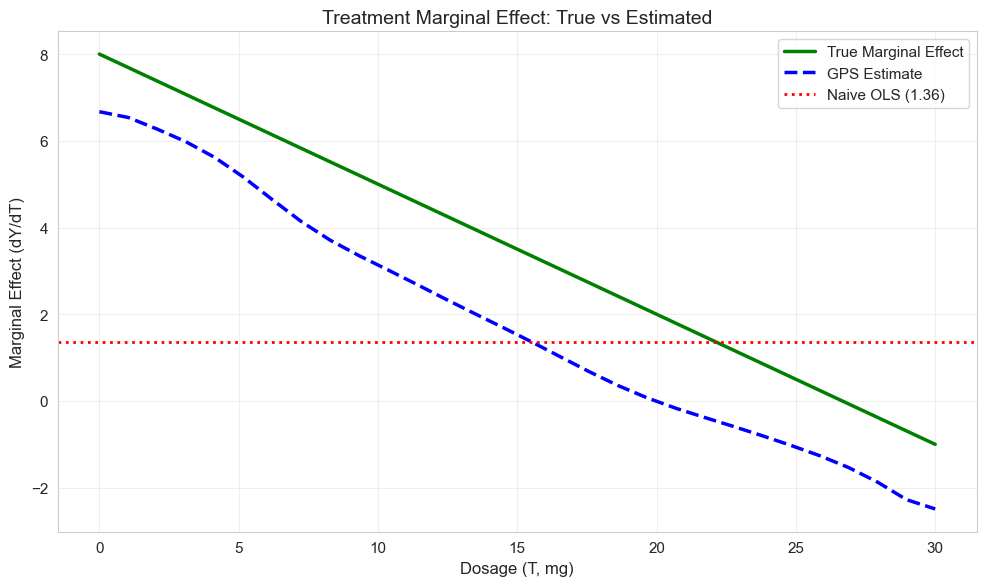

Naive OLS marginal effect: 1.3557
GPS mean marginal effect: 1.8320
True mean marginal effect: 3.5000


In [10]:
# Comparison: Marginal Effect

# Naive regression
naive_marginal = np.full(len(t_grid), naive_coef)

# GPS marginal effect (numerical differentiation)
gps_marginal = np.gradient(adrf_estimate, t_grid[1] - t_grid[0])

# True marginal effect: d/dt(30 + 8t - 0.15t^2) = 8 - 0.3t
true_marginal = 8 - 0.3 * t_grid

plt.figure(figsize=(10, 6))
plt.plot(t_grid, true_marginal, 'g-', linewidth=2.5, label='True Marginal Effect')
plt.plot(t_grid, gps_marginal, 'b--', linewidth=2.5, label='GPS Estimate')
plt.axhline(y=naive_coef, color='r', linestyle=':', linewidth=2, label=f'Naive OLS ({naive_coef:.2f})')

plt.xlabel('Dosage (T, mg)', fontsize=12)
plt.ylabel('Marginal Effect (dY/dT)', fontsize=12)
plt.title('Treatment Marginal Effect: True vs Estimated', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Naive OLS marginal effect: {naive_coef:.4f}')
print(f'GPS mean marginal effect: {np.mean(gps_marginal):.4f}')
print(f'True mean marginal effect: {np.mean(true_marginal):.4f}')


## 6. LLM 기반 연속형 처치변수 자동 탐지

LLM을 사용하여 데이터 설명으로부터 처치변수가 연속형인지 판단하고, 적절한 분석 방법을 추천한다.

In [11]:
from pydantic import BaseModel
from typing import Optional

# Pydantic 모델: 연속형 처치변수 정보
class ContinuousTreatmentInfo(BaseModel):
    """LLM 구조화 출력: 연속형 처치변수 탐지 결과"""
    is_continuous: bool
    treatment_variable: str
    reasoning: str
    recommended_method: str
    possible_confounders: list

# 테스트 시나리오
scenario_text = """우리는 2000명의 환자에 대해 임상 시험을 수행했습니다.
주요 변수들:
- 처치: 항생제 투약량 (mg, 범위 100~500)
- 결과: 회복까지의 일수 (days)
- 공변수: 환자의 나이, 초기 증상 심각도, 기존 질환

우리는 투약량이 회복 시간에 미치는 영향을 알고 싶습니다.
투약량이 높을수록 빠르게 회복되나요?
"""

print(f"시나리오:\n{scenario_text}")

시나리오:
우리는 2000명의 환자에 대해 임상 시험을 수행했습니다.
주요 변수들:
- 처치: 항생제 투약량 (mg, 범위 100~500)
- 결과: 회복까지의 일수 (days)
- 공변수: 환자의 나이, 초기 증상 심각도, 기존 질환

우리는 투약량이 회복 시간에 미치는 영향을 알고 싶습니다.
투약량이 높을수록 빠르게 회복되나요?



In [12]:
# LLM 호출: 구조화된 출력으로 처치변수 판단

prompt = f"""다음 임상 시나리오를 분석하세요. 처치변수가 연속형인지 판단하고,
해당하는 인과추론 방법을 추천하세요.

{scenario_text}"""

try:
    response = client.chat.completions.parse(
        model='gpt-4o-mini',
        messages=[{'role': 'user', 'content': prompt}],
        response_format=ContinuousTreatmentInfo,
    )

    result = response.choices[0].message.parsed

    print('LLM 분석 결과:')
    print(f'  연속형 여부: {result.is_continuous}')
    print(f'  처치변수: {result.treatment_variable}')
    print(f'  추천 방법: {result.recommended_method}')
    print(f'  교란변수: {result.possible_confounders}')
    print(f'  근거: {result.reasoning}')

except Exception as e:
    print(f'LLM 호출 오류: {e}')
    print('\n대체: 수동 분석')
    print('- 처치변수: 항생제 투약량 (연속형)')
    print('- 추천 방법: 일반화 성향점수 (GPS) + 용량-반응 함수 (ADRF)')
    print('- 교란변수: 나이, 초기 증상 심각도, 기존 질환')


LLM 호출 오류: Error code: 400 - {'error': {'message': "Invalid schema for response_format 'ContinuousTreatmentInfo': In context=('properties', 'possible_confounders', 'items'), schema must have a 'type' key.", 'type': 'invalid_request_error', 'param': 'response_format', 'code': None}}

대체: 수동 분석
- 처치변수: 항생제 투약량 (연속형)
- 추천 방법: 일반화 성향점수 (GPS) + 용량-반응 함수 (ADRF)
- 교란변수: 나이, 초기 증상 심각도, 기존 질환
